# Module 2 Case Study — Loan Prediction, End-to-End Preprocessing

**In plain English:** a bank ("Dream Housing Finance") wants to automatically
decide whether to approve a home loan based on the applicant's details. The
real dataset behind this is genuinely messy — some fields are missing, some
are text categories, some are numbers on wildly different scales. This
notebook takes that mess through every preprocessing step needed before any
model could use it: joining two related tables, cleaning, encoding, scaling,
picking the useful columns, and compressing everything with PCA.

Every step also explains *why* that choice was made, not just what code does it.


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pipeline as pl

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load from two sources and join them

The original dataset was split into two related tables to mirror a real
system, where applicant demographics and loan/financial numbers often live in
separate tables:

- `data/raw/applicants.csv` — who the person is (Gender, Married, Dependents,
  Education, Self_Employed, Property_Area)
- `data/raw/loan_data.db` — a **SQLite database**, table `loan_financials`
  (income, loan amount, credit history, loan status)

We load the financials with a real SQL query, and join the two tables on
`Loan_ID` — the same way you'd join a `customers` table to an `orders` table.

In [2]:
import sqlite3

applicants = pd.read_csv("../data/raw/applicants.csv")
print("applicants:", applicants.shape)

with sqlite3.connect("../data/raw/loan_data.db") as conn:
    financials = pd.read_sql("SELECT * FROM loan_financials", conn)
print("financials (via SQL):", financials.shape)

raw = applicants.merge(financials, on="Loan_ID", how="inner")
print("joined:", raw.shape)
raw.head()

applicants: (614, 7)
financials (via SQL): (614, 7)
joined: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,LP001002,Male,No,0,Graduate,No,Urban,5849,0.0,NaN,360.0,1.0,Y
1,LP001003,Male,Yes,1,Graduate,No,Rural,4583,1508.0,128.0,360.0,1.0,N
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,3000,0.0,66.0,360.0,1.0,Y
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,2583,2358.0,120.0,360.0,1.0,Y
4,LP001008,Male,No,0,Graduate,No,Urban,6000,0.0,141.0,360.0,1.0,Y


## 2. Clean — missing values and outliers

First, let's see exactly what's missing and how skewed the numeric columns are.

In [3]:
missing = raw.isnull().sum()
missing[missing > 0]

Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64

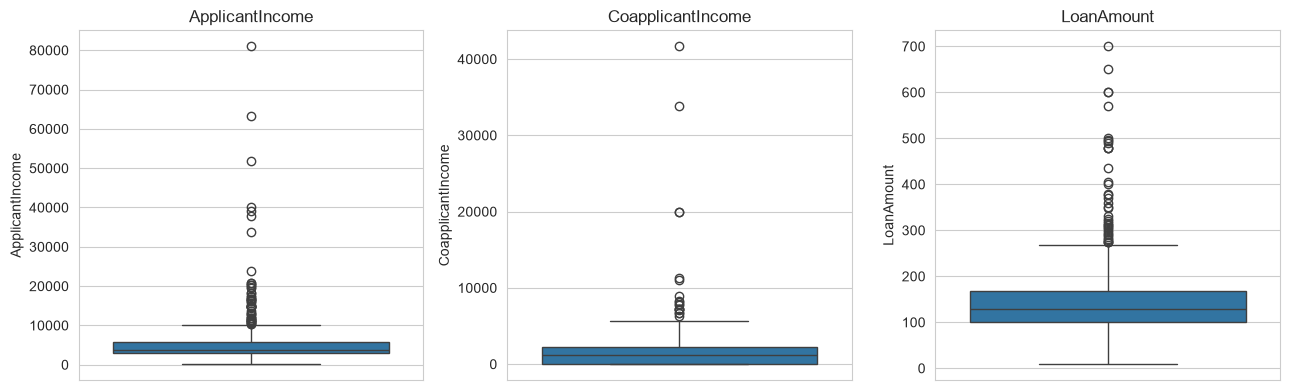

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]):
    sns.boxplot(y=raw[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**The cleaning rules we're applying** (implemented in `clean()` in
`src/pipeline.py`, not just here — so they're reusable on new data):

- Categorical columns with a handful of missing values (`Gender`, `Married`,
  `Dependents`, `Self_Employed`) → fill with the **mode** (most common value).
  With so few gaps (2–5% of rows), the mode is a safe, simple default.
- `Loan_Amount_Term` and `Credit_History` *look* numeric but only take a
  handful of discrete values (e.g. 360 shows up in 512 of 614 rows) — they
  behave like categories, so they also get mode-filled.
- `LoanAmount` → fill with the **median**, not the mean, because a few very
  large loans pull the mean upward; the median is more representative of a
  "typical" loan.
- `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount` → **cap outliers at the
  99th percentile** instead of deleting those rows. We keep every applicant,
  but stop a handful of extreme incomes from distorting scaling and PCA later.

In [5]:
cleaned = pl.clean(raw)
print("Missing values after cleaning:", cleaned.isnull().sum().sum())
cleaned[["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]].describe()

Missing values after cleaning: 0


,ApplicantIncome,CoapplicantIncome,LoanAmount
count,614.000000,614.000000,614.000000
mean,5209.602394,1483.654967,144.702101
std,4533.747664,1831.226927,78.645640
min,150.000000,0.000000,9.000000
25%,2877.500000,0.000000,100.250000
50%,3812.500000,1188.500000,128.000000
75%,5795.000000,2297.250000,164.750000
max,32540.410000,8895.890000,495.870000


## 3. Encode categories, scale numbers

Models only understand numbers, so every text category needs to become one:

- Yes/No and Male/Female style columns → 0/1
- `Dependents` ("0","1","2","3+") → 0/1/2/3 (there's a natural order, so this
  is fine as plain numbers)
- `Property_Area` (Rural/Semiurban/Urban — no natural order between them) →
  one-hot columns, one flag column per category
- The numeric columns (income, loan amount, term) get **standardised** (mean
  0, standard deviation 1) so a column like income (thousands) doesn't
  dominate a column like credit history (0 or 1) just because its raw numbers
  are bigger.

In [6]:
encoded = pl.encode_and_scale(cleaned)
encoded.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Area_Rural,Area_Semiurban,Area_Urban
0,LP001002,1,0,0,1,0,0.141146,-0.810858,-0.212545,0.273231,1.0,1,0,0,1
1,LP001003,1,1,1,1,0,-0.138321,0.013305,-0.212545,0.273231,1.0,0,1,0,0
2,LP001005,1,1,0,1,1,-0.487765,-0.810858,-1.001534,0.273231,1.0,1,0,0,1
3,LP001006,1,1,0,0,0,-0.579817,0.477853,-0.314350,0.273231,1.0,1,0,0,1
4,LP001008,1,0,0,1,0,0.174479,-0.810858,-0.047112,0.273231,1.0,1,0,0,1


## 4. Correlation analysis and feature selection

Now we check which columns actually relate to `Loan_Status` (did the loan get
approved?), and drop the ones that don't carry much signal, or that just
duplicate another column's information.

In [7]:
corr_with_target = encoded.drop(columns=["Loan_ID"]).corr()["Loan_Status"].sort_values(key=abs, ascending=False)
corr_with_target

Loan_Status          1.000000
Credit_History       0.540556
Area_Semiurban       0.136540
Area_Rural          -0.100694
Married              0.091478
Education            0.085884
Area_Urban          -0.043621
LoanAmount          -0.041038
Loan_Amount_Term    -0.022549
Gender               0.017987
Dependents           0.010118
CoapplicantIncome   -0.004579
Self_Employed       -0.003700
ApplicantIncome      0.003383
Name: Loan_Status, dtype: float64

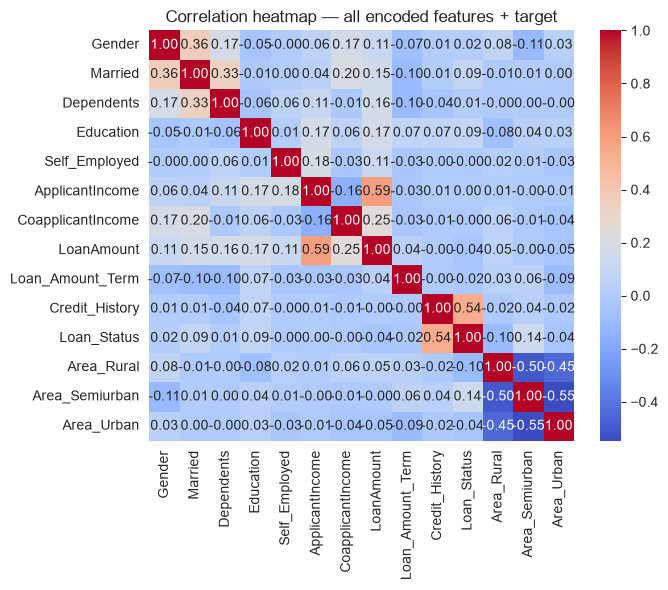

In [8]:
plt.figure(figsize=(7, 6))
sns.heatmap(encoded.drop(columns=["Loan_ID"]).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap — all encoded features + target")
plt.tight_layout()
plt.show()

In [9]:
selected, dropped = pl.select_features(encoded)
print("Kept columns:", selected.columns.tolist())
print("\nDropped, and why:")
for col, reason in dropped.items():
    print(f"  - {col}: {reason}")

Kept columns: ['Loan_ID', 'Married', 'Education', 'LoanAmount', 'Credit_History', 'Area_Rural', 'Area_Semiurban', 'Area_Urban', 'Loan_Status']

Dropped, and why:
  - Gender: weak correlation with target (0.018)
  - Dependents: weak correlation with target (0.010)
  - Self_Employed: weak correlation with target (-0.004)
  - ApplicantIncome: weak correlation with target (0.003)
  - CoapplicantIncome: weak correlation with target (-0.005)
  - Loan_Amount_Term: weak correlation with target (-0.023)


**Why these were dropped:** `Gender`, `Self_Employed`, `Dependents`,
`ApplicantIncome`, `CoapplicantIncome`, and `Loan_Amount_Term` all had a
correlation with `Loan_Status` weaker than 0.03 — essentially no relationship
in this dataset. That's a bit counter-intuitive (you might expect income to
matter a lot!) but it matches a well-known pattern in this specific dataset:
**`Credit_History` dominates the approval decision almost by itself**, which
is exactly what shows up as by far the strongest correlation above.

What's left (`Married`, `Education`, `LoanAmount`, `Credit_History`, and the
`Property_Area` flags) are the columns that actually carry useful signal
without duplicating each other.

## 5. PCA — compressing the numeric features

PCA finds a smaller number of "combined" columns that still capture most of
the original spread in the data. We compare how much of the original
variation is preserved with 2, 3, and 5 components.

In [10]:
pca_input_cols = ["LoanAmount", "Credit_History"] + [c for c in selected.columns if c.startswith("Area_")]
pca_summary = pl.apply_pca(selected, pca_input_cols, component_counts=(2, 3, 5))
pca_summary

,n_components,explained_variance_ratio_per_component,total_explained_variance
0,2,"[0.561, 0.2]",0.760
1,3,"[0.561, 0.2, 0.171]",0.931
2,5,"[0.561, 0.2, 0.171, 0.069, 0.0]",1.000


With only 5 numeric-ish columns to begin with, PCA doesn't have much to
compress — by 5 components we've simply kept all the original information
(100% explained variance), and even 2-3 components already capture the large
majority of it. PCA would matter much more on a wider dataset with dozens of
numeric columns; here it's mostly a sanity check that our feature selection
didn't leave in a lot of redundant information.

## 6. Reproduce the processed dataset via the reusable pipeline

Everything above is also wrapped into `src/pipeline.py` as plain functions, so
the exact same steps can run on brand-new raw data with one function call —
not just inside this notebook.

In [11]:
reproduced = pl.run_pipeline()
reproduced.head()

Processed dataset: 614 rows, 9 columns
Dropped features:
  - Gender: weak correlation with target (0.018)
  - Dependents: weak correlation with target (0.010)
  - Self_Employed: weak correlation with target (-0.004)
  - ApplicantIncome: weak correlation with target (0.003)
  - CoapplicantIncome: weak correlation with target (-0.005)
  - Loan_Amount_Term: weak correlation with target (-0.023)
Saved -> C:\Users\neeha\OneDrive\Desktop\Gray Matter Technologies\GrayMatterTechnologies\02-module2-case-study-preprocessing\data\processed\loan_processed.csv


,Loan_ID,Married,Education,LoanAmount,Credit_History,Area_Rural,Area_Semiurban,Area_Urban,Loan_Status
0,LP001002,0,1,-0.212545,1.0,0,0,1,1
1,LP001003,1,1,-0.212545,1.0,1,0,0,0
2,LP001005,1,1,-1.001534,1.0,0,0,1,1
3,LP001006,1,0,-0.314350,1.0,0,0,1,1
4,LP001008,0,1,-0.047112,1.0,0,0,1,1


In [12]:
# Sanity check: running the pipeline function gives the same result we built step-by-step above
assert reproduced.equals(selected), "Pipeline output should match the step-by-step version"
print("Pipeline reproduces the processed dataset correctly.")

Pipeline reproduces the processed dataset correctly.


## Summary — what we did and why

- Joined two related tables (a CSV of applicant demographics + a SQLite table
  of loan financials) on `Loan_ID`, using a real SQL query for one of them.
- Filled missing values with the mode (categories) or median (skewed
  numbers), and capped a handful of extreme incomes/loan amounts instead of
  deleting those applicants.
- Turned every text category into numbers, and standardised the numeric
  columns so none of them unfairly dominates just by having bigger raw values.
- Found that `Credit_History` is overwhelmingly the strongest predictor of
  loan approval in this dataset, and dropped 6 columns that added little to
  no signal (income variables, self-employment, dependents, gender).
- Confirmed PCA doesn't lose meaningful information at 3-5 components on this
  already-small feature set.
- Packaged all of it into `src/pipeline.py` so it can be re-run on new raw
  data with `python src/pipeline.py`, producing
  `data/processed/loan_processed.csv`.
